# Data Analytics III - Assignment 10

### Import required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix

In [26]:
from sklearn.preprocessing import StandardScaler

### Loading data

In [2]:
df = pd.read_csv("Iris.csv")

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.shape

(150, 6)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [6]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [7]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop('Id', axis = 1, inplace = True)

In [10]:
df.columns

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='str')

### Data visualisation

<Axes: xlabel='Species', ylabel='SepalLengthCm'>

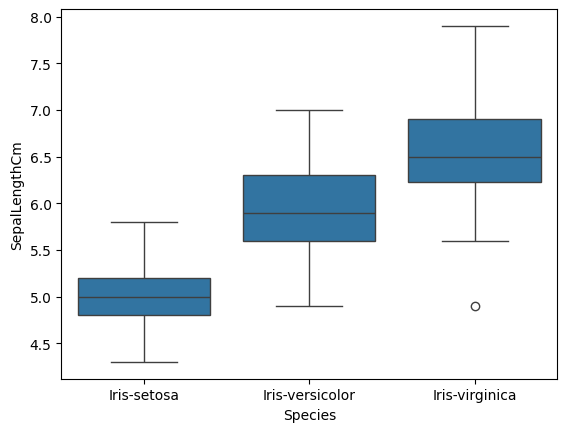

In [11]:
sns.boxplot(x = 'Species', y = 'SepalLengthCm', data = df)

<Axes: xlabel='Species', ylabel='PetalLengthCm'>

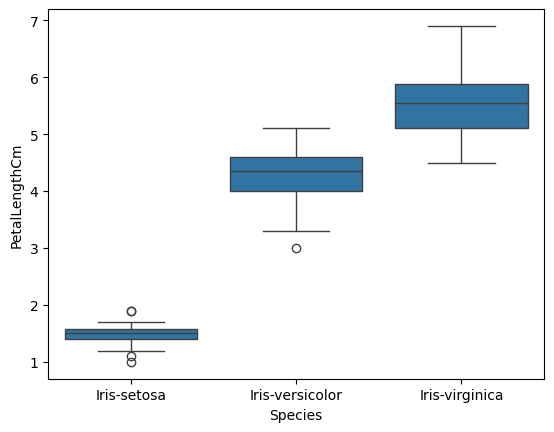

In [12]:
sns.boxplot(x = 'Species', y = 'PetalLengthCm', data = df)

<Axes: xlabel='Species', ylabel='SepalWidthCm'>

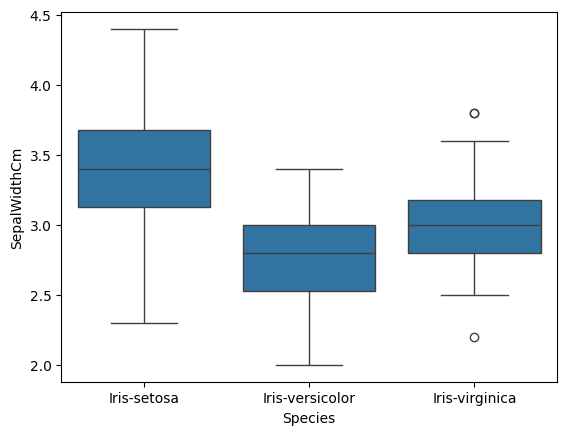

In [13]:
sns.boxplot(x = 'Species', y = 'SepalWidthCm', data = df)

<Axes: xlabel='Species', ylabel='PetalWidthCm'>

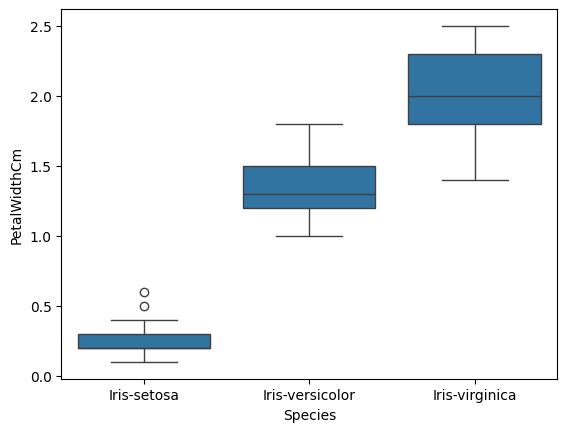

In [14]:
sns.boxplot(x = 'Species', y = 'PetalWidthCm', data = df)

<Axes: >

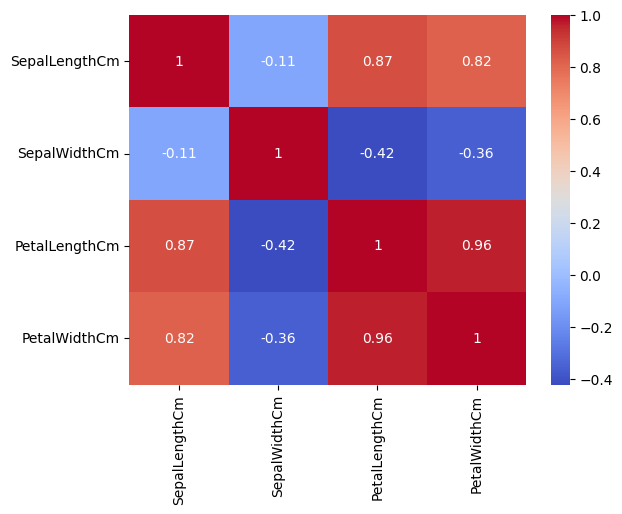

In [20]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap = 'coolwarm', annot = True)

### Training model

In [22]:
X = df.drop('Species', axis = 1)
y = df['Species']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 42)

In [24]:
model = GaussianNB()

In [27]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [29]:
y_pred = model.predict(X_test)

### Model metrics

In [30]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]


In [31]:
class_report = classification_report(y_test, y_pred)

In [32]:
print(class_report)

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      0.92      0.96        13
 Iris-virginica       0.93      1.00      0.96        13

       accuracy                           0.98        45
      macro avg       0.98      0.97      0.97        45
   weighted avg       0.98      0.98      0.98        45



In [33]:
results = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})

In [34]:
results

,Actual,Predicted
0,Iris-versicolor,Iris-versicolor
1,Iris-setosa,Iris-setosa
2,Iris-virginica,Iris-virginica
3,Iris-versicolor,Iris-versicolor
4,Iris-versicolor,Iris-versicolor
5,Iris-setosa,Iris-setosa
6,Iris-versicolor,Iris-versicolor
7,Iris-virginica,Iris-virginica
8,Iris-versicolor,Iris-versicolor
9,Iris-versicolor,Iris-versicolor


In [36]:
print(results[results['Actual']!= results['Predicted']])

             Actual       Predicted
15  Iris-versicolor  Iris-virginica


In [37]:
accuracy = accuracy_score(y_test, y_pred)

In [38]:
print(accuracy)

0.9777777777777777
